In [1]:
import os
import sys
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import torch
import wandb
import numpy as np
from safetensors.torch import save_model
from torch import nn, optim

from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    create_data_loader,
    get_dataset_class,
)
from nnscaling.log import logger
from nnscaling.models import MLP
from nnscaling.scripts.common import load_config, train_one_epoch
from nnscaling.utils import get_device, set_seed
from nnscaling.visualization import plot_decision_boundary

%load_ext autoreload
%autoreload 2


In [2]:
device = get_device()
seed = 42
batch_size = 256
num_epochs = 3_000
set_seed(seed)

In [3]:
# Dataset config
dataset_config = DatasetConfig(
    dataset_name="YinYangBinaryDataset",
    num_samples=3_000,
    split="train",
    seed=42,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
dataset = DatasetClass(config=dataset_config)
train_loader = create_data_loader(dataset, batch_size=batch_size, global_seed=seed)

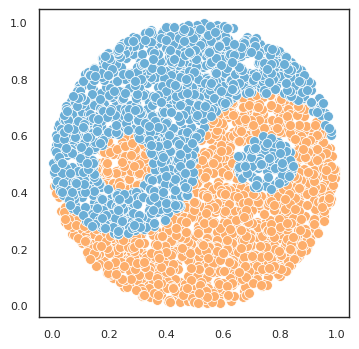

In [4]:
# Figure and plot
fig, ax = plt.subplots()

labels = [0, 1]
colors = [
    aesthetics.SeabornColors.orange,
    aesthetics.SeabornColors.blue,
]
for i, label in enumerate(labels):
    sns.scatterplot(
        x=dataset.features[dataset.labels.squeeze() == label, 0].numpy(),
        y=dataset.features[dataset.labels.squeeze() == label, 1].numpy(),
        ax=ax,
        color=colors[i],
        marker="o",
        s=50,
    )

plt.show()

In [5]:
model = MLP(
    config=[
        4,
        4,
        4,
        4,
        4,
        4,
        4,
        4,
        4,
        4,
        4,
    ],
    in_features=dataset.features.shape[-1],
    out_features=2,
    nonlinearity=nn.ReLU,
)
model.to(device)
_ = model.train()
model.summary()

Layer (type (var_name))                  Param #
MLP (MLP)                                --
+ Sequential (_features)                 --
|    + LinearLayer (0)                   --
|    |    + Linear (linear)              12
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (1)                   --
|    |    + Linear (linear)              20
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (2)                   --
|    |    + Linear (linear)              20
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (3)                   --
|    |    + Linear (linear)              20
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (4)                   --
|    |    + Linear (linear)              20
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (5)                   --
|    |    + Linear (linear)              20
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (6)                   --
|    |    + Linear (linear)

In [6]:
# Define loss and optimiser
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    params=model.parameters(),
    lr=1e-3,
    # weight_decay=1e-4,
)

In [7]:
# Loop over epochs
for epoch in range(num_epochs):
    # Train step
    train_loss = train_one_epoch(
        model=model,
        train_loader=train_loader,
        device=device,
        criterion=loss,
        optimizer=optimizer,
    )

    # Print loss
    if (epoch + 1) % 100 == 0:
        logger.info(f"Epoch {epoch + 1}/{num_epochs}, Loss: {train_loss:.4f}")

2024-11-13 15:58:11 - INFO - Epoch 100/3000, Loss: 0.6932
2024-11-13 15:58:17 - INFO - Epoch 200/3000, Loss: 0.6931
2024-11-13 15:58:24 - INFO - Epoch 300/3000, Loss: 0.6931
2024-11-13 15:58:31 - INFO - Epoch 400/3000, Loss: 0.6931
2024-11-13 15:58:37 - INFO - Epoch 500/3000, Loss: 0.6931
2024-11-13 15:58:43 - INFO - Epoch 600/3000, Loss: 0.6931
2024-11-13 15:58:49 - INFO - Epoch 700/3000, Loss: 0.6932
2024-11-13 15:58:55 - INFO - Epoch 800/3000, Loss: 0.6931
2024-11-13 15:59:02 - INFO - Epoch 900/3000, Loss: 0.6931
2024-11-13 15:59:08 - INFO - Epoch 1000/3000, Loss: 0.6931
2024-11-13 15:59:14 - INFO - Epoch 1100/3000, Loss: 0.6931
2024-11-13 15:59:20 - INFO - Epoch 1200/3000, Loss: 0.6932
2024-11-13 15:59:26 - INFO - Epoch 1300/3000, Loss: 0.6931
2024-11-13 15:59:32 - INFO - Epoch 1400/3000, Loss: 0.6931
2024-11-13 15:59:38 - INFO - Epoch 1500/3000, Loss: 0.6931
2024-11-13 15:59:44 - INFO - Epoch 1600/3000, Loss: 0.6931
2024-11-13 15:59:50 - INFO - Epoch 1700/3000, Loss: 0.6931
2024-1

KeyboardInterrupt: 

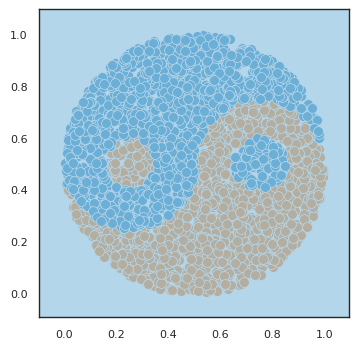

In [ ]:
plot_decision_boundary(
    model,
    model.state_dict(),
    dataset.features,
    dataset.labels.squeeze(),
    labels=[0, 1],
)

In [ ]:
model.hook_model()
_ = model.forward(dataset.features.to(device))
data = model.get_activations()[1].cpu().numpy()
labels = dataset.labels.flatten().cpu().numpy()

In [ ]:
# Function to perform PCA using only NumPy
def pca_numpy(data, n_components=3):
    # Center the data (subtract the mean)
    data_mean = np.mean(data, axis=0)
    centered_data = data - data_mean

    # Compute the covariance matrix
    covariance_matrix = np.cov(centered_data, rowvar=False)

    # Perform eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Sort the eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, sorted_indices]

    # Select the top n_components eigenvectors
    principal_components = eigenvectors[:, :n_components]

    # Project the data onto the principal components
    reduced_data = np.dot(centered_data, principal_components)

    return reduced_data


# Handle dimensionality
if data.shape[-1] > 3:
    # Apply PCA using NumPy to reduce to 3 dimensions
    data = pca_numpy(data, n_components=3)
elif data.shape[-1] == 2:
    data = np.hstack((data, np.zeros((data.shape[0], 1))))

In [ ]:
# Unpack the coordinates
x, y, z = zip(*data)

# Create the 3D scatter plot
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=x,
            y=y,
            z=z,
            mode="markers",
            marker=dict(size=2, color=labels, colorscale="Bluered"),
        )
    ]
)
fig.show()